## Walkability In San Fracisco, California

This Walkability Index is structured around three dimensions: **Accessibility**, **Street Network**, and **Environment**. Together, these capture the core conditions that shape walkability in urban settings. Under accessibility, being close to public transit and having a lot of amenities nearby, such as banks, cafes and stores, has a positive impact on walkability. More densely populated areas are also more likely to score higher on walkability than sparsely populated areas. The construction of the street network itself can influence walkability, with greater intersection density and a shorter distance to nearby amenities leading to a better commuting experience. Finally, different aspects of the environment may factor into how walkable a neighborhood is perceived to be. Streets that are very hilly, or with a steep slope, will require more effort to pass, contributing to a lower walkability score. On the other hand, streets with many trees make the commuting experience more pleasant, increasing the walkability score. Mixed land use should similarly correlate positively with walkability: mixes of different types of areas, such as commercial and residential, imply a greater coverage of services in an area, and improve the convenience and overall wakling experience.

**A. Accessibility**<br>
Accessibility reflects how easily residents can reach daily needs and mobility options. Areas with more amenities support shorter trips and more local activity. Proximity to public transit increases non-automobile travel options and reduces reliance on private vehicles. Population density is included because denser urban areas typically support more services, more transit coverage, and shorter travel distances, all of which positively correlate with walkability.

**B. Street Network**<br>
The structure of the street network affects how direct, connected, and efficient walking routes are. Higher intersection density provides more route choices and shorter block lengths-conditions strongly linked to pedestrian activity. Shorter average walking distance to amenities further indicates how easily residents can access services.

**C. Environment**<br>
Environmental conditions influence both the physical effort and the comfort of walking. Streets with steep slopes require more exertion and tend to reduce walkability. In contrast, greater tree density contributes to shade, comfort, and a more pleasant walking experience. Finally, mixed land use, representing the diversity of land-use types within an area, is associated with vibrant walkable neighborhoods, where commercial, residential, and civic uses co-locate to support daily needs within short distances.

### A. Accessibility
1. Number of amenities **(amenity_sp)**
2. Proximity to public transit **(nodes_muni_sp)**
3. Population density **(Worldpop raster)**
### B. Street Network
1. Intersection density **(nodes_sp)**
2. Average walking distance to amenity **(nodes_dist_sp)**
### C. Environment
1. Average street slope **(slope_sp)**
2. Green space - tree density **(trees_sp)**
3. Mixed land use - **(entropy raster, processed separately in ArcPro)**

In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
from rasterio.transform import from_origin
from rasterio.features import rasterize
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.plot import show
from shapely.geometry import box
from shapely.geometry import Polygon
import numpy as np
import os
from glob import glob

### References
- **User Guide**: https://osmnx.readthedocs.io/en/stable/getting-started.html
- **Notebook tutorials**: https://github.com/gboeing/osmnx-examples/blob/main/notebooks/01-overview-osmnx.ipynb
- **Walkability index reference**:
    - https://ijbnpa.biomedcentral.com/articles/10.1186/s12966-022-01270-8#:~:text=Selection%20of%20components,-We%20employed%20a&text=Specifically%20for%20walkability%2C%20the%20basic,Wagtendonk%20and%20Lakerveld%20%5B42%5D.
    - https://atl.sites.olt.ubc.ca/research/walkability-index/#:~:text=The%20Health%20&%20Community%20Design%20Lab%20developed,number%20of%20street%20intersections%20in%20a%20neighborhood

## Create a polygon grid as the basis for spatial joins and later raster analysis.
Raster grid is the unit of analysis. This is key because index components will be merged to this grid and rasterized at the end to create an index. Working with an intitial polygon rather than a raster grid is simpler and more efficient for spatial joins.

In [3]:
## 1. Load SF ZIP code geojson
# source: https://geodata.lib.berkeley.edu/catalog/ark28722-s7jg7w
sf_zip = gpd.read_file(
    r"C:\Users\Yulia\Documents\professional_development\sf_walkability\data\uc_berkeley_sf_zipcodes.json",
    driver='GeoJSON'
)

## 2. Project to a metric CRS (meters) for grid generation
## https://epsg.io/3310
sf = sf_zip.to_crs(epsg=3310)
sf_union = sf.unary_union  # combined polygon (MultiPolygon)

## 3. Grid cell size in meters
cell_size = 500  # 500 m; used 250 m before - but too small and computationally intensive for meaningful analysis

## 4. Get bounding box of the union
minx, miny, maxx, maxy = sf_union.bounds

## 5. Generate polygon grid
polygons = []
x = minx
while x < maxx:
    y = miny
    while y < maxy:
        polygons.append(
            Polygon([
                (x, y),
                (x + cell_size, y),
                (x + cell_size, y + cell_size),
                (x, y + cell_size)
            ])
        )
        y += cell_size
    x += cell_size

grid = gpd.GeoDataFrame(geometry=polygons, crs=sf.crs)

## 6. Clip grid to SF boundary
grid_clipped = gpd.overlay(grid, sf, how="intersection")

# create an id column for the grid geometry so each grid has its own id - sequential, starting at 1 
grid['grid_id'] = pd.Series(range(len(grid))) + 1

## 7. Save to geojson
# grid.to_file(
#     r"C:\Users\Yulia\Documents\professional_development\sf_walkability\data\sf_grid.geojson",
#     driver="GeoJSON"
#)

C:\Users\Yulia\AppData\Local\Temp\ipykernel_25396\3002422089.py:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  sf_union = sf.unary_union  # combined polygon (MultiPolygon)


In [4]:
grid.head(3)

,geometry,grid_id
0,"POLYGON ((-221179.547 -31616.095, -220679.547 ...",1
1,"POLYGON ((-221179.547 -31116.095, -220679.547 ...",2
2,"POLYGON ((-221179.547 -30616.095, -220679.547 ...",3


<AxesSubplot: >

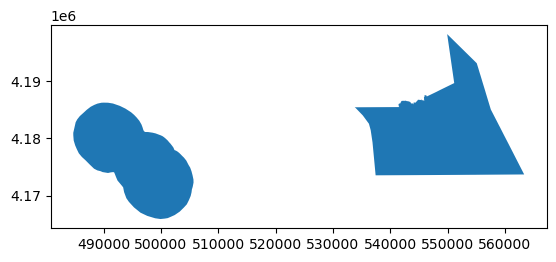

In [4]:
# get SF boundaries from osmnx - they look a bit rough
sf_boundary = ox.geocoder.geocode_to_gdf("San Francisco, California, USA")
sf_boundary = ox.projection.project_gdf(sf_boundary)
sf_boundary.plot()

In [5]:
# get walking network graph for San Francisco, CA
walk_g = ox.graph.graph_from_place("San Francisco, California, USA", network_type="walk")
walk_g_proj = ox.projection.project_graph(walk_g, to_crs=grid.crs) # project to grid CRS so the units are in meters

# extract nodes and edges from the walkability graph
nodes, edges = ox.graph_to_gdfs(walk_g_proj)

In [6]:
basic_stats = ox.basic_stats(walk_g_proj)
print(basic_stats)

{'n': 49435, 'm': 149764, 'k_avg': 6.059027005158288, 'edge_length_total': 6613771.782586619, 'edge_length_avg': 44.16129231715645, 'streets_per_node_avg': 3.0310913320521897, 'streets_per_node_counts': {0: 0, 1: 7965, 2: 1, 3: 24304, 4: 16899, 5: 233, 6: 30, 7: 2, 8: 1}, 'streets_per_node_proportions': {0: 0.0, 1: 0.161120663497522, 2: 2.0228582987761707e-05, 3: 0.49163548093456055, 4: 0.3418428239101851, 5: 0.004713259836148478, 6: 0.0006068574896328512, 7: 4.0457165975523414e-05, 8: 2.0228582987761707e-05}, 'intersection_count': 41470, 'street_length_total': 3306885.8912932957, 'street_segment_count': 74882, 'street_length_avg': 44.16129231715627, 'circuity_avg': 1.0541738083898373, 'self_loop_proportion': 0.0019497342485510537}


## A. Accessibility

### A1. Create a raster input: number of amenities per grid

In [7]:
# get amenity POIs
# note that this will include duplicates - to deduplicate, I'm going to subset to points
amenity = ox.features.features_from_place("San Francisco, California, USA", tags={'amenity':True}) # get all amenity types
amenity.head(5)

geometry      addr:city addr:housenumber  \
element id                                                                      
node    61670779  POINT (-122.43102 37.77214)  San Francisco              530   
        61671096  POINT (-122.43122 37.77191)            NaN              547   
        61671382  POINT (-122.43176 37.77205)            NaN              582   
        61672275  POINT (-122.43142 37.77189)            NaN              557   
        61673273  POINT (-122.43326 37.77186)  San Francisco              668   

                 addr:state    addr:street            alt_name amenity  \
element id                                                               
node    61670779         CA  Haight Street  Woods Beer;Lowside     pub   
        61671096        NaN  Haight Street                 NaN     pub   
        61671382        NaN  Haight Street                 NaN     pub   
        61672275        NaN  Haight Street                 NaN     pub   
        61673273         CA  Haight Street                 NaN     pub   

                   branch contact:facebook contact:instagram  ... highway  \
element id                                                    ...           
node    61670779  Lowside      woodsbeerco         woodsbeer  ...     NaN   
        61671096      NaN              NaN               NaN  ...     NaN   
        61671382      NaN              NaN               NaN  ...     NaN   
        61672275      NaN              NaN               NaN  ...     NaN   
        61673273      NaN      dannycoyles               NaN  ...     NaN   

                 artist changing_table:fee tourist_bus garage  \
element id                                                      
node    61670779    NaN                NaN         NaN    NaN   
        61671096    NaN                NaN         NaN    NaN   
        61671382    NaN                NaN         NaN    NaN   
        61672275    NaN                NaN         NaN    NaN   
        61673273    NaN                NaN         NaN    NaN   

                 handwashing:description roof:material healthcare:for  \
element id                                                              
node    61670779                     NaN           NaN            NaN   
        61671096                     NaN           NaN            NaN   
        61671382                     NaN           NaN            NaN   
        61672275                     NaN           NaN            NaN   
        61673273                     NaN           NaN            NaN   

                 community:wikidata name:kn  
element id                                   
node    61670779                NaN     NaN  
        61671096                NaN     NaN  
        61671382                NaN     NaN  
        61672275                NaN     NaN  
        61673273                NaN     NaN  

[5 rows x 748 columns]

<AxesSubplot: >

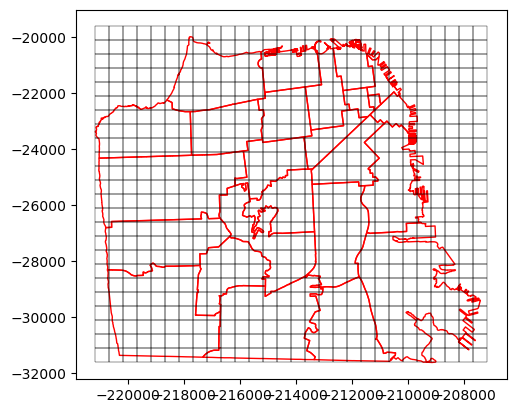

In [8]:
# plot the polygon grid
ax = sf.plot(facecolor="none", edgecolor="red", linewidth=1)
grid.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.3)

True


<AxesSubplot: >

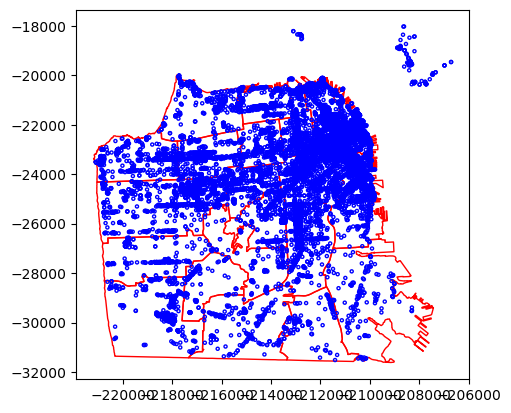

In [9]:
# plot amenities to see how they are distributed
# appear to be concentrated in NE
# converting to same projection as grid for spatial join
amenity = amenity.to_crs(grid.crs)
print(grid.crs == amenity.crs)

# deduplicating
amenity = amenity[amenity.geometry.type == "Point"]
amenity = amenity.drop_duplicates(subset=['geometry'])

ax = sf.plot(facecolor="none", edgecolor="red", linewidth=1)
amenity.plot(ax=ax, facecolor="none", edgecolor="blue", markersize=5)

In [10]:
amenity['osm_count'] = 1
amenity_join = gpd.sjoin(grid, amenity, how='left', predicate = 'intersects')
amenity_join.sort_values(by='osm_count').head(5)

,geometry,grid_id,element,id,addr:city,addr:housenumber,addr:state,addr:street,alt_name,amenity,...,artist,changing_table:fee,tourist_bus,garage,handwashing:description,roof:material,healthcare:for,community:wikidata,name:kn,osm_count
10,"POLYGON ((-221179.547 -26616.095, -220679.547 ...",11,node,1.276333e+10,NaN,NaN,NaN,NaN,NaN,bench,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
454,"POLYGON ((-212179.547 -20616.095, -211679.547 ...",455,node,1.139082e+10,NaN,NaN,NaN,NaN,NaN,waste_basket,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
454,"POLYGON ((-212179.547 -20616.095, -211679.547 ...",455,node,1.139082e+10,NaN,NaN,NaN,NaN,NaN,bicycle_parking,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
454,"POLYGON ((-212179.547 -20616.095, -211679.547 ...",455,node,9.896489e+09,NaN,NaN,NaN,NaN,NaN,waste_basket,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
454,"POLYGON ((-212179.547 -20616.095, -211679.547 ...",455,node,1.004832e+10,NaN,NaN,NaN,NaN,NaN,fast_food,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [11]:
amenity_join = amenity_join[['grid_id', 'name', 'amenity', 'osm_count', 'geometry']]
amenity_join['osm_count'].isna().sum() # 222 grids have no amenities

222

In [12]:
# summarize count of number of amenities by id; using osm_count column because it's non-missing while name and amenity are missing
amenity_counts = amenity_join.groupby('grid_id')['osm_count'].count()
print(max(amenity_counts)) # making sure I joined correctly - max should be more than 1

286


In [13]:
len(grid) == len(amenity_counts)

True

In [14]:
amenity_counts = amenity_counts.reset_index()
amenity_counts = amenity_counts.rename(columns={'osm_count':'amenity_count'})
amenity_counts.sort_values(by='amenity_count', ascending=False).head(10)

,grid_id,amenity_count
523,524,286
474,475,272
473,474,249
475,476,247
454,455,235
206,207,228
498,499,225
497,498,221
522,523,210
449,450,207


In [15]:
amenity_sp = pd.merge(grid, amenity_counts, how='left', left_on='grid_id', right_on='grid_id')
amenity_sp.head(5)

,geometry,grid_id,amenity_count
0,"POLYGON ((-221179.547 -31616.095, -220679.547 ...",1,0
1,"POLYGON ((-221179.547 -31116.095, -220679.547 ...",2,0
2,"POLYGON ((-221179.547 -30616.095, -220679.547 ...",3,0
3,"POLYGON ((-221179.547 -30116.095, -220679.547 ...",4,0
4,"POLYGON ((-221179.547 -29616.095, -220679.547 ...",5,0


(array([538.,  62.,  29.,  19.,   9.,   3.,   2.,   5.,   3.,   2.]),
 array([  0. ,  28.6,  57.2,  85.8, 114.4, 143. , 171.6, 200.2, 228.8,
        257.4, 286. ]),
 <BarContainer object of 10 artists>)

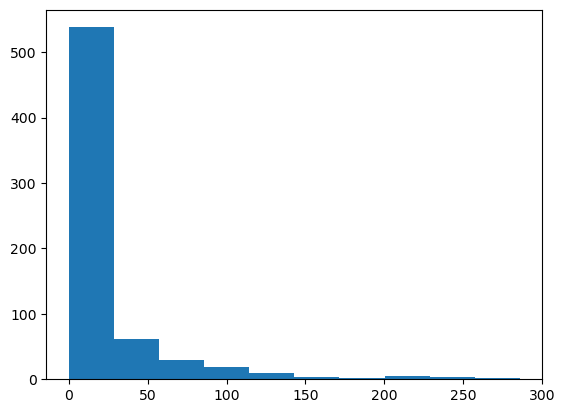

In [16]:
# large range in values, most values are between 0-50
plt.hist(x=amenity_counts['amenity_count'], bins=10) 

### A2. Creater a raster input: proximity to public transit

In [17]:
muni_stops = gpd.read_file(r"C:\Users\Yulia\Documents\professional_development\sf_walkability\data\muni_stops.gpkg") # this was downloaded from SF Open Data

# extract nodes and edges from the walkability graph
nodes, edges = ox.graph_to_gdfs(walk_g_proj)
muni_stops = muni_stops.to_crs(grid.crs)

In [18]:
muni_clipped = gpd.clip(muni_stops, grid)

muni_nearest_node = ox.distance.nearest_nodes(
    walk_g_proj,
    X=muni_clipped.geometry.x,
    Y=muni_clipped.geometry.y
)

# remove duplicates if multiple muni stops map to same node
muni_nearest_node = list(set(muni_nearest_node))

# compute shortest path lengths from all nodes to the nearest muni node
muni_distances_dict = nx.multi_source_dijkstra_path_length(
    walk_g_proj,
    sources=muni_nearest_node,
    weight='length'
)

# attach distances back to nodes GeoDataFrame
nodes["dist_to_muni"] = nodes.index.map(muni_distances_dict)

In [19]:
nodes_muni_join = gpd.sjoin(grid, nodes, how='left', predicate = 'intersects')
nodes_muni_join = nodes_muni_join.groupby("grid_id")["dist_to_muni"].mean().reset_index()

nodes_muni_sp = pd.merge(grid, nodes_muni_join, how='left', left_on='grid_id', right_on='grid_id')
nodes_muni_sp['dist_to_muni'].isna().sum()

173

(array([339.,  93.,  37.,   9.,   9.,   4.,   6.,   0.,   1.,   1.]),
 array([  35.38273242,  202.92400686,  370.46528131,  538.00655576,
         705.5478302 ,  873.08910465, 1040.63037909, 1208.17165354,
        1375.71292799, 1543.25420243, 1710.79547688]),
 <BarContainer object of 10 artists>)

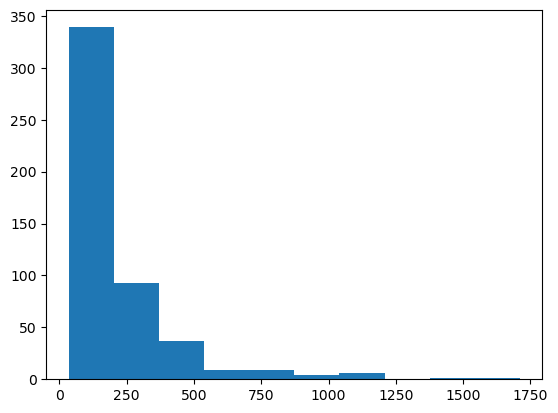

In [20]:
plt.hist(x=nodes_muni_sp['dist_to_muni'], bins=10) 

## B. Street Network

### B1. Create a raster input: intersection density

In [21]:
# extract nodes and edges from the walkability graph
nodes, edges = ox.graph_to_gdfs(walk_g_proj)

In [6]:
degree = dict(walk_g_proj.degree()) # get number of legs for each intersection
nodes["degree"] = nodes.index.map(degree) # add them as a column
nodes_final = nodes[nodes["degree"] >= 3]

In [7]:
nodes_final['osm_point'] = 1
nodes_join = gpd.sjoin(grid, nodes_final, how='left', predicate = 'intersects')

C:\Users\Yulia\AppData\Local\ESRI\conda\envs\spatial_custom_fixed\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [8]:
nodes_counts = nodes_join.groupby('grid_id')['osm_point'].count()
print(max(nodes_counts))

360


In [9]:
len(grid) == len(nodes_counts)

True

In [10]:
nodes_counts = nodes_counts.reset_index()
nodes_counts = nodes_counts.rename(columns={'osm_point':'node_count'})
nodes_counts.sort_values(by='node_count', ascending=False).head(10)

,grid_id,node_count
499,500,360
181,182,327
147,148,303
123,124,254
496,497,253
497,498,249
149,150,244
205,206,243
451,452,243
498,499,241


In [11]:
nodes_sp = pd.merge(grid, nodes_counts, how='left', left_on='grid_id', right_on='grid_id')
nodes_sp.head(5)

,geometry,grid_id,node_count
0,"POLYGON ((-221179.547 -31616.095, -220679.547 ...",1,0
1,"POLYGON ((-221179.547 -31116.095, -220679.547 ...",2,0
2,"POLYGON ((-221179.547 -30616.095, -220679.547 ...",3,0
3,"POLYGON ((-221179.547 -30116.095, -220679.547 ...",4,0
4,"POLYGON ((-221179.547 -29616.095, -220679.547 ...",5,0


In [12]:
nodes_sp['node_count'].value_counts(ascending=False).head(10)

node_count
0     178
33     11
57      9
46      8
66      8
63      7
71      7
68      6
90      6
39      6
Name: count, dtype: int64

(array([292., 138.,  96.,  63.,  48.,  19.,  11.,   2.,   1.,   2.]),
 array([  0.,  36.,  72., 108., 144., 180., 216., 252., 288., 324., 360.]),
 <BarContainer object of 10 artists>)

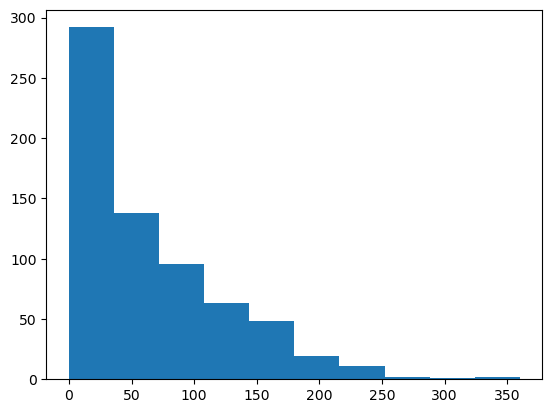

In [29]:
plt.hist(x=nodes_counts['node_count'], bins=10) 

In [16]:
nodes_sp['node_count'].describe()

count    672.000000
mean      61.700893
std       62.696165
min        0.000000
25%        0.000000
50%       48.500000
75%       96.250000
max      360.000000
Name: node_count, dtype: float64

(array([178.,   0.,   0.,   4.,   0.,   4.,   0.,   2.,   3.,   4.,   3.,
          2.,   6.,   6.,   7.,  16.,  21.,  30.,  25.,  29.,  44.,  51.,
         53.,  47.,  39.,  47.,  30.,  12.,   6.,   3.]),
 array([0.        , 0.19629593, 0.39259186, 0.5888878 , 0.78518373,
        0.98147966, 1.17777559, 1.37407152, 1.57036746, 1.76666339,
        1.96295932, 2.15925525, 2.35555118, 2.55184712, 2.74814305,
        2.94443898, 3.14073491, 3.33703084, 3.53332677, 3.72962271,
        3.92591864, 4.12221457, 4.3185105 , 4.51480643, 4.71110237,
        4.9073983 , 5.10369423, 5.29999016, 5.49628609, 5.69258203,
        5.88887796]),
 <BarContainer object of 30 artists>)

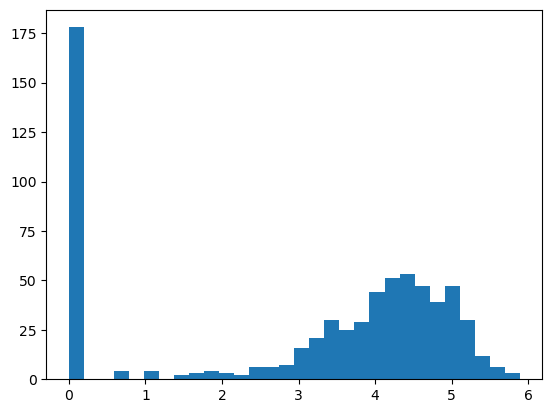

In [25]:
plt.hist(np.log1p(nodes_sp['node_count']), bins=30)

{'whiskers': [<matplotlib.lines.Line2D at 0x294f93d42d0>,
 'caps': [<matplotlib.lines.Line2D at 0x294ec2e1b50>,
 'boxes': [<matplotlib.lines.Line2D at 0x294f35924d0>],
 'medians': [<matplotlib.lines.Line2D at 0x294ec2e3b50>],
 'fliers': [<matplotlib.lines.Line2D at 0x294eb0b0890>],
 'means': []}

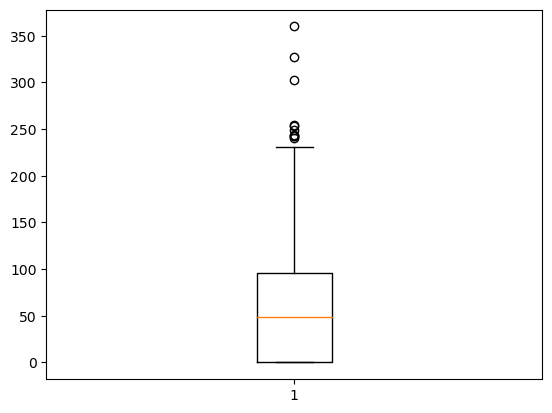

In [26]:
plt.boxplot(nodes_sp['node_count'])

In [27]:
# nodes_sp.to_file(
#     r"C:\Users\Yulia\Documents\professional_development\sf_walkability\data\intersection_density_sp.geojson",
#     driver="GeoJSON"
# )

### B2. Create a raster input: average walking distance

In [30]:
# extract nodes and edges from the walkability graph
nodes, edges = ox.graph_to_gdfs(walk_g_proj)

In [31]:
# map each amenity to nearest graph node
amenity_clipped = gpd.clip(amenity, grid)

amenity_nearest_node = ox.distance.nearest_nodes(
    walk_g_proj,
    X=amenity_clipped.geometry.x,
    Y=amenity_clipped.geometry.y
)

# remove duplicates if multiple amenities map to same node
amenity_nearest_node = list(set(amenity_nearest_node))

# compute shortest path lengths from all nodes to the nearest amenity node
distances_dict = nx.multi_source_dijkstra_path_length(
    walk_g_proj,
    sources=amenity_nearest_node,
    weight='length'
)

# attach distances back to nodes GeoDataFrame
nodes["dist_to_amenity"] = nodes.index.map(distances_dict)

In [32]:
nodes_dist_join = gpd.sjoin(grid, nodes, how='left', predicate = 'intersects')
nodes_dist_mean = nodes_dist_join.groupby("grid_id")["dist_to_amenity"].mean().reset_index()

In [33]:
nodes_dist_sp = pd.merge(grid, nodes_dist_mean, how='left', left_on='grid_id', right_on='grid_id')

In [34]:
nodes_dist_sp['dist_to_amenity'].isna().sum()

173

(array([270., 143.,  40.,  22.,  14.,   4.,   2.,   1.,   1.,   2.]),
 array([   0.        ,  123.85611339,  247.71222677,  371.56834016,
         495.42445354,  619.28056693,  743.13668032,  866.9927937 ,
         990.84890709, 1114.70502047, 1238.56113386]),
 <BarContainer object of 10 artists>)

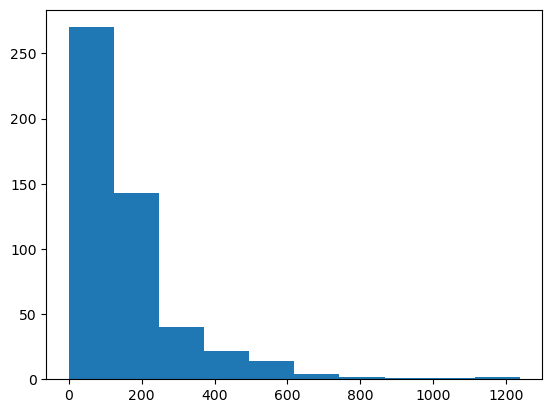

In [35]:
plt.hist(x=nodes_dist_mean['dist_to_amenity'], bins=10) 

## C. Environment

### C1. Slope

In [36]:
def resample_raster(src_path, ref_path, out_path, nodata_value=None):
    with rasterio.open(src_path) as src, rasterio.open(ref_path) as ref:

        # target properties from reference raster
        dst_crs = ref.crs
        dst_transform = ref.transform
        dst_width = ref.width
        dst_height = ref.height

        # creating blank matrix to populate with reprojected data
        nodata = -9999
        if nodata_value is not None:
            nodata = src.nodata if src.nodata is not None else nodata_value
        
        dst_data = np.zeros((dst_height, dst_width), dtype=src.dtypes[0])

        # reprojecting and resampling src to dst 
        reproject(
            source=rasterio.band(src, 1),
            destination=dst_data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear,
            dst_nodata=nodata
        )

        Print("Reprojection complete!")

        # copying reference raster profile
        dst_profile = ref.profile.copy()
        dst_profile.update(
            dtype=dst_data.dtype,
            nodata=nodata,
            count=1
        )

        # writing reprojected, resampled raster to disk
        with rasterio.open(out_path, 'w', **dst_profile) as dst:
            dst.write(dst_data, 1)

        print(f"Process complete! Final raster written to {out_path}")   

In [37]:
slope_path = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\data\slope\USGS_13_n38w123_20250826.tif"
dst_raster = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\data\slope\USGS_13_n38w123_20250826_reproj.tif"
dst_crs = grid.crs  

with rasterio.open(slope_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height
    })

    with rasterio.open(dst_raster, 'w', **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear
            )

In [38]:
# get walking network graph for San Francisco, CA
walk_g = ox.graph.graph_from_place("San Francisco, California, USA", network_type="walk")
walk_g_proj = ox.projection.project_graph(walk_g, to_crs=grid.crs) # project to grid CRS so the units are in meters

In [39]:
# extract elevation grades from elevation raster using osmnx
walk_g_proj = ox.elevation.add_node_elevations_raster(walk_g_proj, filepath=dst_raster)
walk_g_proj = ox.elevation.add_edge_grades(walk_g_proj, add_absolute=True)

In [40]:
gdf_edges = ox.graph_to_gdfs(walk_g_proj, nodes=False)
gdf_edges.head(3)

osmid  highway  oneway reversed     length  \
u         v         key                                                   
31843591  364491481 0    396123635  footway   False    False   9.371367   
364491481 31843591  0    396123635  footway   False     True   9.371367   
          361141994 0     32399102  footway   False    False  22.590075   

                            grade  grade_abs  \
u         v         key                        
31843591  364491481 0    0.243489   0.243489   
364491481 31843591  0   -0.243489   0.243489   
          361141994 0    0.079666   0.079666   

                                                                  geometry  \
u         v         key                                                      
31843591  364491481 0    LINESTRING (-209036.349 -31601.944, -209036.52...   
364491481 31843591  0    LINESTRING (-209036.52 -31592.576, -209036.349...   
          361141994 0    LINESTRING (-209036.52 -31592.576, -209036.955...   

                        name service lanes maxspeed width access bridge  ref  \
u         v         key                                                        
31843591  364491481 0    NaN     NaN   NaN      NaN   NaN    NaN    NaN  NaN   
364491481 31843591  0    NaN     NaN   NaN      NaN   NaN    NaN    NaN  NaN   
          361141994 0    NaN     NaN   NaN      NaN   NaN    NaN    NaN  NaN   

                        junction tunnel  
u         v         key                  
31843591  364491481 0        NaN    NaN  
364491481 31843591  0        NaN    NaN  
          361141994 0        NaN    NaN

In [41]:
gdf_edges['grade'].value_counts()

grade
 0.000000    12044
 0.319128        2
-0.013113        2
-0.319128        2
 0.013113        2
             ...  
-0.004771        1
 0.022418        1
-0.020363        1
 0.025703        1
-0.007940        1
Name: count, Length: 137713, dtype: int64

In [42]:
slope_join = gpd.sjoin(grid, gdf_edges, how='left', predicate = 'intersects')
slope_join = slope_join[['grid_id', 'grade', 'grade_abs', 'geometry']]

# get average absolute slope for each grid
slope_avg = slope_join.groupby('grid_id')['grade_abs'].mean()
print(len(grid) == len(slope_avg))

True


In [43]:
slope_avg = slope_avg.reset_index()
print(slope_avg['grade_abs'].isna().sum())

170


In [44]:
slope_sp = pd.merge(grid, slope_avg, how='left', left_on='grid_id', right_on='grid_id')
slope_sp.head(5)

,geometry,grid_id,grade_abs
0,"POLYGON ((-221179.547 -31616.095, -220679.547 ...",1,NaN
1,"POLYGON ((-221179.547 -31116.095, -220679.547 ...",2,NaN
2,"POLYGON ((-221179.547 -30616.095, -220679.547 ...",3,NaN
3,"POLYGON ((-221179.547 -30116.095, -220679.547 ...",4,NaN
4,"POLYGON ((-221179.547 -29616.095, -220679.547 ...",5,NaN


(array([210., 168.,  82.,  35.,   5.,   0.,   1.,   0.,   0.,   1.]),
 array([0.00100713, 0.02640939, 0.05181166, 0.07721393, 0.10261619,
        0.12801846, 0.15342072, 0.17882299, 0.20422526, 0.22962752,
        0.25502979]),
 <BarContainer object of 10 artists>)

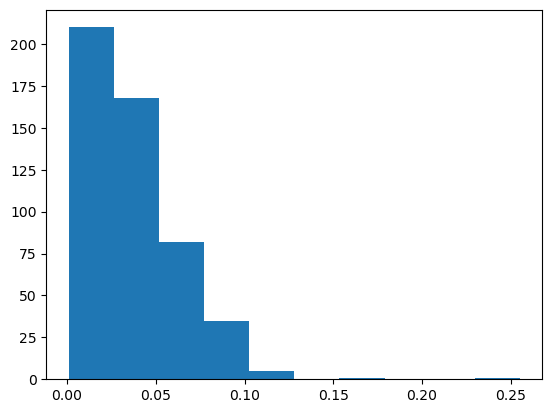

In [45]:
plt.hist(x=slope_avg['grade_abs'], bins=10) 

### C2. Create a raster input: tree density

In [46]:
trees = pd.read_csv(r'C:\Users\Yulia\Documents\professional_development\sf_walkability\data\Street_Tree_List_20251120.csv') # downloaded from SF Open Data
trees_geo = gpd.points_from_xy(trees['Longitude'], trees['Latitude'])

trees_gdf = gpd.GeoDataFrame(trees,
                             geometry=trees_geo,
                             crs="EPSG:4326")

trees_gdf = trees_gdf.to_crs(crs=grid.crs)
trees_gdf = gpd.clip(trees_gdf, grid)

C:\Users\Yulia\AppData\Local\Temp\ipykernel_14004\3011521358.py:1: DtypeWarning: Columns (4,10) have mixed types. Specify dtype option on import or set low_memory=False.
  trees = pd.read_csv(r'C:\Users\Yulia\Documents\professional_development\sf_walkability\data\Street_Tree_List_20251120.csv') # downloaded from SF Open Data


<AxesSubplot: >

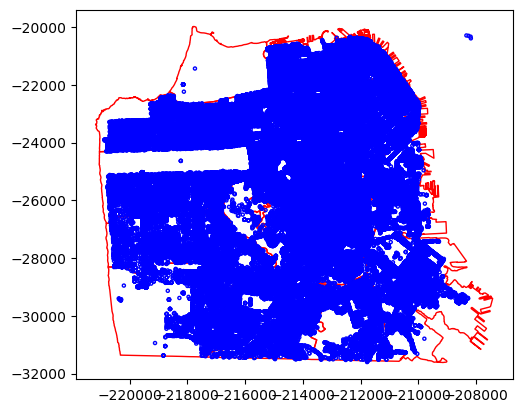

In [47]:
# lots of trees everywhere
ax = sf.plot(facecolor="none", edgecolor="red", linewidth=1)
trees_gdf.plot(ax=ax, facecolor="none", edgecolor="blue", markersize=5)

In [48]:
trees_gdf['tree_point'] = 1
trees_join = gpd.sjoin(grid, trees_gdf, how='left', predicate = 'intersects')

In [49]:
trees_counts = trees_join.groupby('grid_id')['tree_point'].count()
print(max(trees_counts))

1575


In [50]:
trees_counts = trees_counts.reset_index()
trees_counts = trees_counts.rename(columns={'tree_point':'tree_count'})
trees_counts.sort_values(by='tree_count', ascending=False).head(10)

,grid_id,tree_count
374,375,1575
375,376,1453
391,392,1339
398,399,1188
307,308,1114
276,277,1108
328,329,1106
401,402,1099
370,371,1099
353,354,1096


In [51]:
trees_sp = pd.merge(grid, trees_counts, how='left', left_on='grid_id', right_on='grid_id')
nodes_sp.head(5)

,geometry,grid_id,node_count
0,"POLYGON ((-221179.547 -31616.095, -220679.547 ...",1,0
1,"POLYGON ((-221179.547 -31116.095, -220679.547 ...",2,0
2,"POLYGON ((-221179.547 -30616.095, -220679.547 ...",3,0
3,"POLYGON ((-221179.547 -30116.095, -220679.547 ...",4,0
4,"POLYGON ((-221179.547 -29616.095, -220679.547 ...",5,0


(array([326.,  91.,  73.,  60.,  51.,  38.,  26.,   4.,   1.,   2.]),
 array([   0. ,  157.5,  315. ,  472.5,  630. ,  787.5,  945. , 1102.5,
        1260. , 1417.5, 1575. ]),
 <BarContainer object of 10 artists>)

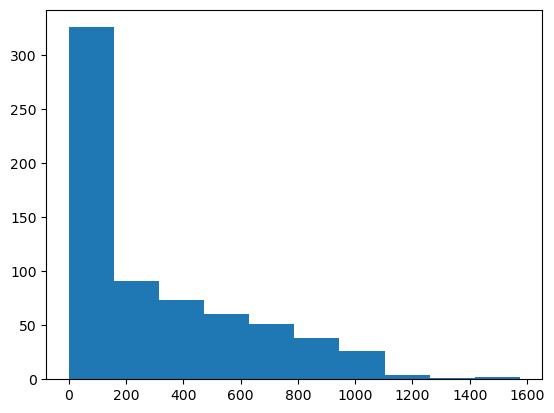

In [52]:
plt.hist(x=trees_counts['tree_count'], bins=10) 

## Index Creation
Rasterize all of the index components and then normalize to create a walkability index raster. 

**Rasterization function to use on most polygon grid input data**

In [53]:
def rasterize_gdf(gdf, resolution, rasterize_field, out_raster_path):
    """
    Rasterizes a GeoDataFrame.
    
    Parameters
    ----------
    gdf : GeoDataFrame
        Polygon input to rasterize.
    resolution : float
        Raster cell size (in units of CRS).
    rasterize_field : str
        Field whose values will be burned into the raster.
    out_raster_path : str
        Output raster file path.
    """

    # 1. Extract bounds
    minx, miny, maxx, maxy = gdf.total_bounds

    # 2. Raster resolution
    res = resolution

    # 3. Define raster dimensions
    width = int((maxx - minx) / res)
    height = int((maxy - miny) / res)

    # 4. Define transform (upper-left origin)
    transform = from_origin(minx, maxy, res, res)

    # 5. Prepare shapes (geom, value)
    gdf[rasterize_field] = gdf[rasterize_field].fillna(0)

    shapes = [
        (geom, value)
        for geom, value in zip(gdf.geometry, gdf[rasterize_field])
    ]

    # 6. Create and write raster
    with rasterio.open(
        out_raster_path,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=1,
        dtype="float32",
        crs=gdf.crs,              
        transform=transform,
    ) as dst:

        burned = rasterize(
            shapes,
            out_shape=(height, width),
            fill=0,
            transform=transform,
            dtype="float32"
        )

        dst.write(burned, 1)

    print("Raster written to:", out_raster_path)


In [54]:
#---------------------------------------------------#
# input: amenity_sp, number of amenities
#---------------------------------------------------#
rasterize_gdf(
    gdf=amenity_sp,
    resolution=500,
    rasterize_field="amenity_count",
    out_raster_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_amenity_count.tif"
)

Raster written to: C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_amenity_count.tif


In [57]:
#---------------------------------------------------#
# input: nodes_muni_sp, proximity to public transit
#---------------------------------------------------#
rasterize_gdf(
    gdf=nodes_muni_sp,
    resolution=500,
    rasterize_field="dist_to_muni",
    out_raster_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_dist_to_muni.tif"
)

Raster written to: C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_dist_to_muni.tif


In [58]:
#---------------------------------------------------#
# input: trees_sp, number of trees
#---------------------------------------------------#
rasterize_gdf(
    gdf=trees_sp,
    resolution=500,
    rasterize_field="tree_count",
    out_raster_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_tree_count.tif"
)

Raster written to: C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_tree_count.tif


In [59]:
#---------------------------------------------------#
# input: nodes_sp, intersection density
#---------------------------------------------------#
rasterize_gdf(
    gdf=nodes_sp,
    resolution=500,
    rasterize_field="node_count",
    out_raster_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_intersection_density.tif"
)

Raster written to: C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_intersection_density.tif


In [60]:
#---------------------------------------------------#
# input: nodes_sp, avg shortest walking distance
#---------------------------------------------------#
rasterize_gdf(
    gdf=nodes_dist_sp,
    resolution=500,
    rasterize_field="dist_to_amenity",
    out_raster_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_avg_walk_dist.tif"
)

Raster written to: C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_avg_walk_dist.tif


In [61]:
#---------------------------------------------------#
# input: slope_sp, avg slope
#---------------------------------------------------#
rasterize_gdf(
    gdf=slope_sp,
    resolution=500,
    rasterize_field="grade_abs",
    out_raster_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_avg_slope.tif"
)

Raster written to: C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_avg_slope.tif


**Function to reproject and resample existing raster inputs.**

In [62]:
def resample_raster(src_path, ref_path, out_path, nodata_value=None):
    with rasterio.open(src_path) as src, rasterio.open(ref_path) as ref:

        # target properties from reference raster
        dst_crs = ref.crs
        dst_transform = ref.transform
        dst_width = ref.width
        dst_height = ref.height

        # creating blank matrix to populate with reprojected data
        nodata = -9999
        if nodata_value is not None:
            nodata = src.nodata if src.nodata is not None else nodata_value
        
        dst_data = np.zeros((dst_height, dst_width), dtype=src.dtypes[0])

        # reprojecting and resampling src to dst 
        reproject(
            source=rasterio.band(src, 1),
            destination=dst_data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear,
            dst_nodata=nodata
        )

        print("Reprojection complete!")

        # copying reference raster profile
        dst_profile = ref.profile.copy()
        dst_profile.update(
            dtype=dst_data.dtype,
            nodata=nodata,
            count=1
        )

        # writing reprojected, resampled raster to disk
        with rasterio.open(out_path, 'w', **dst_profile) as dst:
            dst.write(dst_data, 1)

        print(f"Process complete! Final raster written to {out_path}")        

In [63]:
#---------------------------------------------------#
# input: Worldpop, population density
#---------------------------------------------------#
resample_raster(src_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\data\usa_pop_2025_CN_100m_R2025A_v1.tif",
                 ref_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_intersection_density.tif",
                 nodata_value=None,
                 out_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_worldpop.tif")

Reprojection complete!
Process complete! Final raster written to C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_worldpop.tif


In [64]:
#---------------------------------------------------#
# input: land use mix, entropy 
#---------------------------------------------------#
resample_raster(
    src_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\data\land_use_entropy.tif",
    ref_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_intersection_density.tif",
    out_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_lu_entropy.tif"
)

Reprojection complete!
Process complete! Final raster written to C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_lu_entropy.tif


**Load index components and normalize using z-scores.**

**Function to normalize raster with z-scores.**

In [65]:
def normalize_zscore(src_path, dst_path, reverse_dir=False):
    with rasterio.open(src_path) as src:
        input_raster = src.read(1).astype('float64')  # ensure float

        # handle nodata values
        nodata = src.nodata
        if nodata is not None:
            mask = input_raster != nodata
        else:
            mask = input_raster != -9999  # fallback if nodata not set

        mean = input_raster[mask].mean()
        std_dev = input_raster[mask].std()

        # calculate z-score
        normalized_data = np.zeros_like(input_raster)
        if std_dev == 0:
            normalized_data[mask] = 0
        else:
            normalized_data[mask] = (input_raster[mask] - mean) / std_dev

        # reverse z-score only for valid cells
        if reverse_dir:
            normalized_data[mask] *= -1

        # keep nodata in the output
        # if nodata is not None:
        #     normalized_data[~mask] = nodata

        # copy profile and update dtype
        dst_profile = src.profile.copy()
        dst_profile.update(dtype=rasterio.float64)

        with rasterio.open(dst_path, 'w', **dst_profile) as dst:
            dst.write(normalized_data, 1)


In [66]:
#---------------------------------------------------#
# normalize: number of amenities
#---------------------------------------------------#
normalize_zscore(src_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_amenity_count.tif",
                 dst_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\normalized\input_amenity_count_zscore.tif")

In [67]:
#---------------------------------------------------#
# normalize: mean slope
#---------------------------------------------------#
normalize_zscore(src_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_avg_slope.tif",
                 dst_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\normalized\input_avg_slope_zscore.tif",
                reverse_dir=True)

In [68]:
#---------------------------------------------------#
# normalize: avg dist to amenities
#---------------------------------------------------#
normalize_zscore(src_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_avg_walk_dist.tif",
                 dst_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\normalized\input_avg_walk_dist_zscore.tif",
                reverse_dir=True)

In [69]:
#---------------------------------------------------#
# normalize: avg dist to public transit
#---------------------------------------------------#
normalize_zscore(src_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_dist_to_muni.tif",
                 dst_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\normalized\input_dist_to_muni_zscore.tif",
                reverse_dir=True)

In [70]:
#---------------------------------------------------#
# normalize: intersection density
#---------------------------------------------------#
normalize_zscore(src_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_intersection_density.tif",
                 dst_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\normalized\input_intersection_density_zscore.tif")

In [71]:
#---------------------------------------------------#
# normalize: land use entropy
#---------------------------------------------------#
normalize_zscore(src_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_lu_entropy.tif",
                 dst_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\normalized\input_lu_entropy_zscore.tif")

In [72]:
#---------------------------------------------------#
# normalize: tree count
#---------------------------------------------------#
normalize_zscore(src_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_tree_count.tif",
                 dst_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\normalized\input_tree_count_zscore.tif")

In [73]:
#---------------------------------------------------#
# normalize: Worldpop
#---------------------------------------------------#
normalize_zscore(src_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\input_worldpop.tif",
                 dst_path=r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\normalized\input_worldpop_zscore.tif")

**Stack rasters, normalize again to create the final walkability index. Final index will range from 0 to 1, with 0 indicating lower walkability and 1 a high walkability score.**

In [76]:
inputs_path = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\Index\normalized"
file_list = glob(os.path.join(inputs_path, '*.tif'))
file_list

['C:\\Users\\Yulia\\Documents\\professional_development\\sf_walkability\\Index\\normalized\\input_amenity_count_zscore.tif',
 'C:\\Users\\Yulia\\Documents\\professional_development\\sf_walkability\\Index\\normalized\\input_avg_slope_zscore.tif',
 'C:\\Users\\Yulia\\Documents\\professional_development\\sf_walkability\\Index\\normalized\\input_avg_walk_dist_zscore.tif',
 'C:\\Users\\Yulia\\Documents\\professional_development\\sf_walkability\\Index\\normalized\\input_dist_to_muni_zscore.tif',
 'C:\\Users\\Yulia\\Documents\\professional_development\\sf_walkability\\Index\\normalized\\input_intersection_density_zscore.tif',
 'C:\\Users\\Yulia\\Documents\\professional_development\\sf_walkability\\Index\\normalized\\input_lu_entropy_zscore.tif',
 'C:\\Users\\Yulia\\Documents\\professional_development\\sf_walkability\\Index\\normalized\\input_tree_count_zscore.tif',
 'C:\\Users\\Yulia\\Documents\\professional_development\\sf_walkability\\Index\\normalized\\input_worldpop_zscore.tif']

In [77]:
## double check all rasters are aligned for correct grid-based raster math
with rasterio.open(file_list[0]) as ref:
    ref_shape = ref.shape
    ref_transform = ref.transform
    ref_crs = ref.crs

for f in file_list[1:]:
    with rasterio.open(f) as src:
        if src.shape != ref_shape:
            print(f"Shape mismatch: {f} has shape {src.shape}, expected {ref_shape}")
        if src.transform != ref_transform:
            print(f"Transform mismatch: {f} has transform {src.transform}, expected {ref_transform}")
        if src.crs != ref_crs:
            print(f"CRS mismatch: {f} has CRS {src.crs}, expected {ref_crs}")

In [78]:
# sum up the raster inputs
with rasterio.open(file_list[0]) as src:
    profile = src.profile
    sum_array = src.read(1).astype('float64')
    profile.update(dtype='float64')

for i in range(1, len(file_list)):
    with rasterio.open(file_list[i]) as src:
        if src.profile['crs'] != profile['crs'] or \
        src.profile['transform'] != profile['transform'] or \
        src.profile['width'] != profile['width'] or \
        src.profile['height'] != profile['height']:
            print(f"Profile mismatch for {file_list[i]}. Skipping")
        else:
            data = src.read(1).astype('float64')
            print(f"Raster {i} min: {data.min()}, max: {data.max()}")
            sum_array += data  
            
print(f"Final raster min: {sum_array.min()}, final raster max: {sum_array.max()}")

Raster 1 min: -8.081375225354076, max: 0.9912004172226807
Raster 2 min: -7.135822360079839, max: 0.769274968950194
Raster 3 min: -7.755750969021174, max: 0.8060631240532027
Raster 4 min: -0.9848585302920313, max: 4.761396580246237
Raster 5 min: -1.4662779635850622, max: 1.874509499234996
Raster 6 min: -0.8871471089364404, max: 3.9209871568716284
Raster 7 min: -1.2826641457484018, max: 6.094628536072053
Final raster min: -19.117690959449984, final raster max: 13.002536548642293


In [79]:
# normalize to a scale from 0 to 1
index_min = sum_array.min()
index_max = sum_array.max()

composite_index = (sum_array - index_min) / (index_max - index_min)
print(f"Max: {composite_index.max()}, Min: {composite_index.min()}")

Max: 1.0, Min: 0.0


In [80]:
## export final index - scale from 0 to 1
dst_path = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\normalized\final_walkability_index.tif"
with rasterio.open(dst_path, "w", **profile) as dst:
    dst.write(composite_index, 1)

In [81]:
## export final index - scale from 0 to 100
dst_path = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\normalized\final_walkability_index_100.tif"
with rasterio.open(dst_path, "w", **profile) as dst:
    composite_index_per = composite_index * 100
    dst.write(composite_index_per, 1)

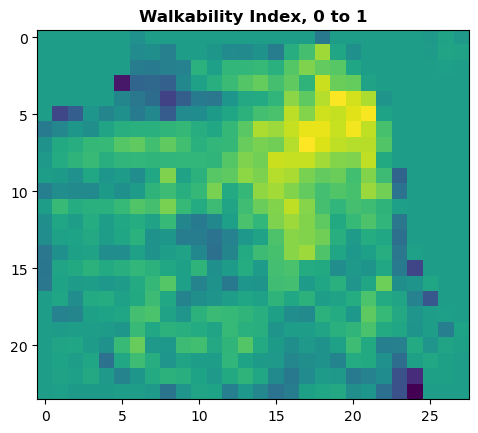

In [82]:
# quick glance at the output
show(composite_index, cmap='viridis', title="Walkability Index, 0 to 1")
plt.show()